In [1]:
import numpy as np
import matplotlib.pyplot as plt


from src.hrp_ordering import hrp_order_from_distance
from src.quantum_encoding import quantum_state_from_features

In [2]:
features = np.load("../../data/features.npy")

N, T, P = features.shape
print("Features shape:", features.shape)

Features shape: (169, 616, 6)


In [3]:
quantum_states = []

for i in range(N):
    psi = quantum_state_from_features(features[i])
    quantum_states.append(psi)

quantum_states = np.array(quantum_states)

print("Quantum states shape:", quantum_states.shape)

Quantum states shape: (169, 6)


In [5]:
D = np.zeros((N, N))

for i in range(N):
    for j in range(N):
        overlap = np.vdot(quantum_states[i], quantum_states[j])
        val = 1.0 - np.abs(overlap)**2
        val = max(val, 0.0)  # protección numérica
        D[i, j] = np.sqrt(val)


In [6]:
print("Diagonal (min, max):", D.diagonal().min(), D.diagonal().max())
print("Symmetry check:", np.allclose(D, D.T))

Diagonal (min, max): 0.0 2.9802322387695312e-08
Symmetry check: True


In [7]:
order_qhrp = hrp_order_from_distance(D)
D_ordered = D[np.ix_(order_qhrp, order_qhrp)]

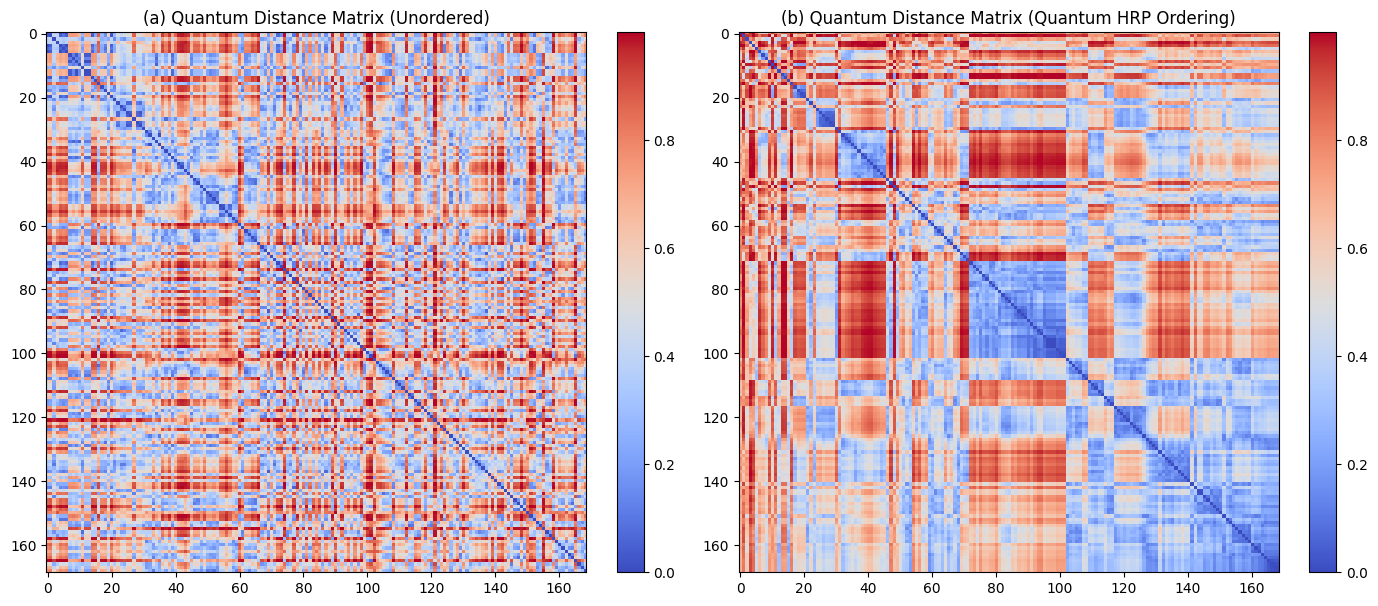

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

im0 = axes[0].imshow(D, cmap="coolwarm")
axes[0].set_title("(a) Quantum Distance Matrix (Unordered)")
plt.colorbar(im0, ax=axes[0], fraction=0.046)

im1 = axes[1].imshow(D_ordered, cmap="coolwarm")
axes[1].set_title("(b) Quantum Distance Matrix (Quantum HRP Ordering)")
plt.colorbar(im1, ax=axes[1], fraction=0.046)

plt.tight_layout()
plt.show()